In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-28-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-01-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-16-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-15-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-21-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/03-02-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-22-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-20-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv
/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-23-2018.csv


In [2]:
# ============================================================
# CSE-CIC CELL 1: Veri Keşfi
# ============================================================
import pandas as pd

# Sadece ilk dosyaya bak — sütun yapısını anla
df_sample = pd.read_csv(
    "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv",
    nrows=5
)
print(f"Sütun sayısı: {len(df_sample.columns)}")
print(f"Sütunlar:\n{list(df_sample.columns)}")
print(f"\nİlk 5 satır:\n{df_sample.head()}")

# Tüm dosyalardaki label dağılımına bak
import os
from pathlib import Path

CSE_DIR = Path("/kaggle/input/datasets/solarmainframe/ids-intrusion-csv")
files = sorted(CSE_DIR.glob("*.csv"))

print("\n--- Label dağılımı (dosya bazında) ---")
for f in files:
    tmp = pd.read_csv(f, usecols=["Label"], low_memory=False)
    print(f"{f.name}: {dict(tmp['Label'].value_counts())}")

Sütun sayısı: 80
Sütunlar:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 

In [1]:
# ============================================================
# CSE-CIC CELL 2 (memory-safe): Dosya dosya yükle, benign'i kırp
# ============================================================
import pandas as pd, numpy as np, warnings, joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

CSE_DIR     = Path("/kaggle/input/datasets/solarmainframe/ids-intrusion-csv")
OUTPUT_DIR  = Path("/kaggle/working/cse_v1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL_COL   = "Label"
BENIGN_STR  = "Benign"
DROP_COLS   = ["Timestamp", "Dst Port"]
BENIGN_PER_FILE = 80_000   # her dosyadan max 80K benign → toplam ~640K
RANDOM_SEED = 42

benign_dfs = []
attack_dfs = []

for f in sorted(CSE_DIR.glob("*.csv")):
    tmp = pd.read_csv(f, low_memory=False)
    tmp = tmp[tmp[LABEL_COL] != LABEL_COL].copy()   # header tekrarı temizle

    ben = tmp[tmp[LABEL_COL] == BENIGN_STR]
    att = tmp[tmp[LABEL_COL] != BENIGN_STR]

    # Benign subsample — dosya başına
    if len(ben) > BENIGN_PER_FILE:
        ben = ben.sample(n=BENIGN_PER_FILE, random_state=RANDOM_SEED)

    benign_dfs.append(ben)
    attack_dfs.append(att)
    print(f"  {f.name}: benign={len(ben)} | attack={len(att)}")
    del tmp

df_benign = pd.concat(benign_dfs, ignore_index=True)
df_attack = pd.concat(attack_dfs, ignore_index=True)
del benign_dfs, attack_dfs

df = pd.concat([df_benign, df_attack], ignore_index=True)
df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
del df_benign, df_attack

print(f"\nToplam: {df.shape}")
print(f"Benign: {(df[LABEL_COL]==BENIGN_STR).sum()} | Attack: {(df[LABEL_COL]!=BENIGN_STR).sum()}")
print(f"\nKategori dağılımı:\n{df[LABEL_COL].value_counts()}")

  02-14-2018.csv: benign=80000 | attack=380949
  02-15-2018.csv: benign=80000 | attack=52498
  02-16-2018.csv: benign=80000 | attack=601802
  02-20-2018.csv: benign=80000 | attack=576191
  02-21-2018.csv: benign=80000 | attack=687742
  02-22-2018.csv: benign=80000 | attack=362
  02-23-2018.csv: benign=80000 | attack=566
  02-28-2018.csv: benign=80000 | attack=68871
  03-01-2018.csv: benign=80000 | attack=93063
  03-02-2018.csv: benign=80000 | attack=286191

Toplam: (3548235, 84)
Benign: 800000 | Attack: 2748235

Kategori dağılımı:
Label
Benign                      800000
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193360
SSH-Bruteforce              187589
Infilteration               161934
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Br

In [2]:
# ============================================================
# CSE-CIC CELL 3: Split & Preprocessing
# ============================================================
attack_cat = df[LABEL_COL].copy()
y = (df[LABEL_COL] != BENIGN_STR).astype(int)
X = df.drop(columns=[LABEL_COL] + [c for c in DROP_COLS if c in df.columns])
del df

for col in X.select_dtypes(include="object").columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X_train_raw, X_test_raw, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y, attack_cat, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
del X, y, attack_cat
for s in [X_train_raw, X_test_raw, y_train, y_test, cat_train, cat_test]:
    s.reset_index(drop=True, inplace=True)

print(f"Train: {X_train_raw.shape} | Normal: {(y_train==0).sum()} | Attack: {(y_train==1).sum()}")
print(f"Test:  {X_test_raw.shape}")

# Preprocessing
X_train_normal = X_train_raw[y_train == 0].copy()
X_train_normal.replace([np.inf, -np.inf], np.nan, inplace=True)
col_medians = X_train_normal.median()
for df_part in [X_train_normal, X_train_raw, X_test_raw]:
    df_part.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_part.fillna(col_medians, inplace=True)

var_mask = X_train_normal.var() > 0.01
X_train_normal = X_train_normal.loc[:, var_mask]
print(f"Varyans sonrası: {var_mask.sum()} feature")

corr_matrix = X_train_normal.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if any(upper[c] > 0.95)]
keep_cols = [c for c in X_train_normal.columns if c not in drop_corr]
print(f"Korelasyon sonrası: {len(drop_corr)} atıldı → {len(keep_cols)} feature kaldı")

scaler = MinMaxScaler()
X_train_scaled     = scaler.fit_transform(X_train_raw[y_train == 0][keep_cols])
X_train_all_scaled = scaler.transform(X_train_raw[keep_cols])
X_test_scaled      = scaler.transform(X_test_raw[keep_cols])
INPUT_DIM_CSE = X_train_scaled.shape[1]

np.save(OUTPUT_DIR / "X_train_normal.npy",  X_train_scaled)
np.save(OUTPUT_DIR / "X_train_all.npy",     X_train_all_scaled)
np.save(OUTPUT_DIR / "X_test.npy",          X_test_scaled)
np.save(OUTPUT_DIR / "y_train.npy",         y_train.values)
np.save(OUTPUT_DIR / "y_test.npy",          y_test.values)
np.save(OUTPUT_DIR / "cat_test.npy",        cat_test.values)
joblib.dump(scaler,    OUTPUT_DIR / "scaler_cse.pkl")
joblib.dump(keep_cols, OUTPUT_DIR / "keep_cols_cse.pkl")

print(f"\n✅ CSE Preprocessing tamam — INPUT_DIM={INPUT_DIM_CSE}")
print(f"Kalan feature'lar: {keep_cols}")

Train: (2838588, 81) | Normal: 640000 | Attack: 2198588
Test:  (709647, 81)
Varyans sonrası: 67 feature
Korelasyon sonrası: 26 atıldı → 41 feature kaldı

✅ CSE Preprocessing tamam — INPUT_DIM=41
Kalan feature'lar: ['Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Var', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'Down/Up Ratio', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Min', 'Src Port']


In [3]:
# ============================================================
# CSE CELL 4: Model Tanımları (UNSW ile aynı)
# ============================================================
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/cse_v1")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

class DeepAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),  nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 128),         nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, input_dim),  nn.Sigmoid()
        )
    def forward(self, x): return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return torch.mean((x - self.forward(x))**2, dim=1).cpu().numpy()

class DenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=8, noise_std=0.05):
        super().__init__()
        self.noise_std = noise_std
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, 64),        nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32),  nn.ReLU(),
            nn.Linear(32, 64),          nn.ReLU(), nn.BatchNorm1d(64),
            nn.Linear(64, 128),         nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128, input_dim),  nn.Sigmoid()
        )
    def forward(self, x, add_noise=False):
        if add_noise and self.training:
            x = torch.clamp(x + torch.randn_like(x) * self.noise_std, 0.0, 1.0)
        return self.decoder(self.encoder(x))
    def reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            return torch.mean((x - self.forward(x, add_noise=False))**2, dim=1).cpu().numpy()

Device: cuda


In [5]:
# ============================================================
# CSE CELL 5: Eğitim Fonksiyonu
# ============================================================
def train_model(model, X_train_np, epochs=50, batch_size=1024, lr=1e-3,
                is_dae=False, model_name="ae"):
    X_tensor  = torch.tensor(X_train_np, dtype=torch.float32)
    loader    = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5)
    criterion = nn.MSELoss()
    model.to(DEVICE)

    history = []
    for epoch in range(1, epochs+1):
        model.train()
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            recon = model(batch, add_noise=True) if is_dae else model(batch)
            loss  = criterion(recon, batch)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss += loss.item() * len(batch)
        avg_loss = epoch_loss / len(X_tensor)
        scheduler.step(avg_loss)
        history.append(avg_loss)
        if epoch % 10 == 0 or epoch == 1:
            print(f"  [{model_name}] Epoch {epoch:3d}/{epochs} | Loss: {avg_loss:.6f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    torch.save(model.state_dict(), OUTPUT_DIR / f"{model_name}_weights.pt")
    np.save(OUTPUT_DIR / f"{model_name}_history.npy", np.array(history))
    print(f"  ✅ {model_name} kaydedildi")
    return history

In [6]:
# ============================================================
# CSE CELL 6: Vanilla AE Eğit
# ============================================================
X_train_normal = np.load(OUTPUT_DIR / "X_train_normal.npy")
INPUT_DIM_CSE  = X_train_normal.shape[1]

print(f"=== CSE Vanilla AE (INPUT_DIM={INPUT_DIM_CSE}) ===")
cse_ae  = DeepAutoencoder(input_dim=INPUT_DIM_CSE, latent_dim=8)
cse_ae_history = train_model(cse_ae, X_train_normal, epochs=50,
                              is_dae=False, model_name="cse_ae")

=== CSE Vanilla AE (INPUT_DIM=41) ===
  [cse_ae] Epoch   1/50 | Loss: 0.028393 | LR: 1.00e-03
  [cse_ae] Epoch  10/50 | Loss: 0.000042 | LR: 1.00e-03
  [cse_ae] Epoch  20/50 | Loss: 0.000020 | LR: 1.00e-03
  [cse_ae] Epoch  30/50 | Loss: 0.000015 | LR: 1.00e-03
  [cse_ae] Epoch  40/50 | Loss: 0.000014 | LR: 1.00e-03
  [cse_ae] Epoch  50/50 | Loss: 0.000009 | LR: 1.00e-03
  ✅ cse_ae kaydedildi


In [7]:
# ============================================================
# CSE CELL 7: DAE Eğit
# ============================================================
print(f"=== CSE Denoising AE (INPUT_DIM={INPUT_DIM_CSE}) ===")
cse_dae = DenoisingAutoencoder(input_dim=INPUT_DIM_CSE, latent_dim=8, noise_std=0.05)
cse_dae_history = train_model(cse_dae, X_train_normal, epochs=50,
                               is_dae=True, model_name="cse_dae")

=== CSE Denoising AE (INPUT_DIM=41) ===
  [cse_dae] Epoch   1/50 | Loss: 0.025936 | LR: 1.00e-03
  [cse_dae] Epoch  10/50 | Loss: 0.000697 | LR: 1.00e-03
  [cse_dae] Epoch  20/50 | Loss: 0.000066 | LR: 1.00e-03
  [cse_dae] Epoch  30/50 | Loss: 0.000058 | LR: 1.00e-03
  [cse_dae] Epoch  40/50 | Loss: 0.000054 | LR: 1.00e-03
  [cse_dae] Epoch  50/50 | Loss: 0.000050 | LR: 1.00e-03
  ✅ cse_dae kaydedildi


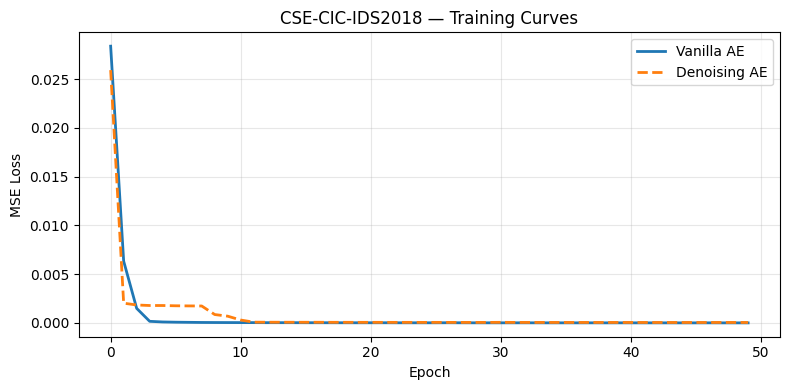

✅ training_curve_cse.png kaydedildi


In [8]:
# ============================================================
# CSE CELL 8: Training Curve
# ============================================================
import matplotlib.pyplot as plt

ae_hist  = np.load(OUTPUT_DIR / "cse_ae_history.npy")
dae_hist = np.load(OUTPUT_DIR / "cse_dae_history.npy")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ae_hist,  label="Vanilla AE",    linewidth=2)
ax.plot(dae_hist, label="Denoising AE",  linewidth=2, linestyle="--")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("CSE-CIC-IDS2018 — Training Curves")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve_cse.png", dpi=150)
plt.show()
print("✅ training_curve_cse.png kaydedildi")

In [9]:
# ============================================================
# CSE CELL 9: Reconstruction Error + Threshold + Metrikler
# ============================================================
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              precision_score, recall_score, f1_score)
import torch
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/cse_v1")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_test_scaled = np.load(OUTPUT_DIR / "X_test.npy")
y_test_np     = np.load(OUTPUT_DIR / "y_test.npy")
cat_test_np   = np.load(OUTPUT_DIR / "cat_test.npy", allow_pickle=True)
INPUT_DIM_CSE = X_test_scaled.shape[1]

# Model ağırlıklarını yükle
cse_ae  = DeepAutoencoder(input_dim=INPUT_DIM_CSE, latent_dim=8).to(DEVICE)
cse_dae = DenoisingAutoencoder(input_dim=INPUT_DIM_CSE, latent_dim=8).to(DEVICE)
cse_ae.load_state_dict(torch.load(OUTPUT_DIR / "cse_ae_weights.pt",  map_location=DEVICE))
cse_dae.load_state_dict(torch.load(OUTPUT_DIR / "cse_dae_weights.pt", map_location=DEVICE))

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
ae_errors  = cse_ae.reconstruction_error(X_test_t)
dae_errors = cse_dae.reconstruction_error(X_test_t)

print(f"AE  errors — mean: {ae_errors.mean():.6f} | max: {ae_errors.max():.4f}")
print(f"DAE errors — mean: {dae_errors.mean():.6f} | max: {dae_errors.max():.4f}")

# Threshold
def get_thresholds(errors, y_true):
    thresh_p95   = np.percentile(errors[y_true == 0], 95)
    fpr, tpr, thresholds = roc_curve(y_true, errors)
    thresh_youden = thresholds[np.argmax(tpr - fpr)]
    return thresh_p95, thresh_youden, fpr, tpr

ae_p95,  ae_youden,  ae_fpr,  ae_tpr  = get_thresholds(ae_errors,  y_test_np)
dae_p95, dae_youden, dae_fpr, dae_tpr = get_thresholds(dae_errors, y_test_np)

# Metrikler
def evaluate(errors, y_true, threshold, model_name, thresh_name):
    preds = (errors > threshold).astype(int)
    roc = roc_auc_score(y_true, errors)
    pr  = average_precision_score(y_true, errors)
    p   = precision_score(y_true, preds, zero_division=0)
    r   = recall_score(y_true, preds, zero_division=0)
    f1  = f1_score(y_true, preds, zero_division=0)
    print(f"[{model_name} | {thresh_name}]  ROC-AUC: {roc:.4f}  PR-AUC: {pr:.4f}  "
          f"Prec: {p:.3f}  Recall: {r:.3f}  F1: {f1:.3f}")
    return roc, pr

print()
ae_roc,  ae_pr  = evaluate(ae_errors,  y_test_np, ae_p95,     "CSE Vanilla AE", "p95")
_,       _      = evaluate(ae_errors,  y_test_np, ae_youden,  "CSE Vanilla AE", "Youden")
dae_roc, dae_pr = evaluate(dae_errors, y_test_np, dae_p95,    "CSE DAE",        "p95")
_,       _      = evaluate(dae_errors, y_test_np, dae_youden, "CSE DAE",        "Youden")

AE  errors — mean: 0.003657 | max: 22.5152
DAE errors — mean: 0.003960 | max: 23.9065

[CSE Vanilla AE | p95]  ROC-AUC: 0.8126  PR-AUC: 0.9314  Prec: 0.964  Recall: 0.391  F1: 0.557
[CSE Vanilla AE | Youden]  ROC-AUC: 0.8126  PR-AUC: 0.9314  Prec: 0.894  Recall: 0.962  F1: 0.927
[CSE DAE | p95]  ROC-AUC: 0.8757  PR-AUC: 0.9542  Prec: 0.973  Recall: 0.529  F1: 0.685
[CSE DAE | Youden]  ROC-AUC: 0.8757  PR-AUC: 0.9542  Prec: 0.918  Recall: 0.944  F1: 0.931


In [10]:
# ============================================================
# CSE CELL 10: Per-Category Recall
# ============================================================
def per_category_recall(errors, y_true, cat_arr, threshold, model_name):
    preds = (errors > threshold).astype(int)
    print(f"\n--- {model_name} (Youden) ---")
    rows = []
    for cat in sorted([c for c in np.unique(cat_arr) if c != "Benign"]):
        mask = cat_arr == cat
        total = mask.sum()
        detected = preds[mask].sum()
        recall = detected / total if total > 0 else 0
        print(f"  {cat:<30} {detected:>6}/{total:<6} = {recall:.3f}")
        rows.append({"category": cat, "recall": recall, "model": model_name})
    return rows

import pandas as pd
cat_rows = []
cat_rows += per_category_recall(ae_errors,  y_test_np, cat_test_np, ae_youden,  "Vanilla AE")
cat_rows += per_category_recall(dae_errors, y_test_np, cat_test_np, dae_youden, "DAE")


--- Vanilla AE (Youden) ---
  Bot                             54360/57401  = 0.947
  Brute Force -Web                  109/137    = 0.796
  Brute Force -XSS                   34/49     = 0.694
  DDOS attack-HOIC               136764/136764 = 1.000
  DDOS attack-LOIC-UDP              353/353    = 1.000
  DDoS attacks-LOIC-HTTP         111968/115034 = 0.973
  DoS attacks-GoldenEye            8224/8224   = 1.000
  DoS attacks-Hulk                92250/92250  = 1.000
  DoS attacks-SlowHTTPTest        28274/28274  = 1.000
  DoS attacks-Slowloris            2182/2182   = 1.000
  FTP-BruteForce                  38990/38990  = 1.000
  Infilteration                   17816/32372  = 0.550
  SQL Injection                      12/16     = 0.750
  SSH-Bruteforce                  37595/37601  = 1.000

--- DAE (Youden) ---
  Bot                             53542/57401  = 0.933
  Brute Force -Web                  115/137    = 0.839
  Brute Force -XSS                   48/49     = 0.980
  DDOS attack-

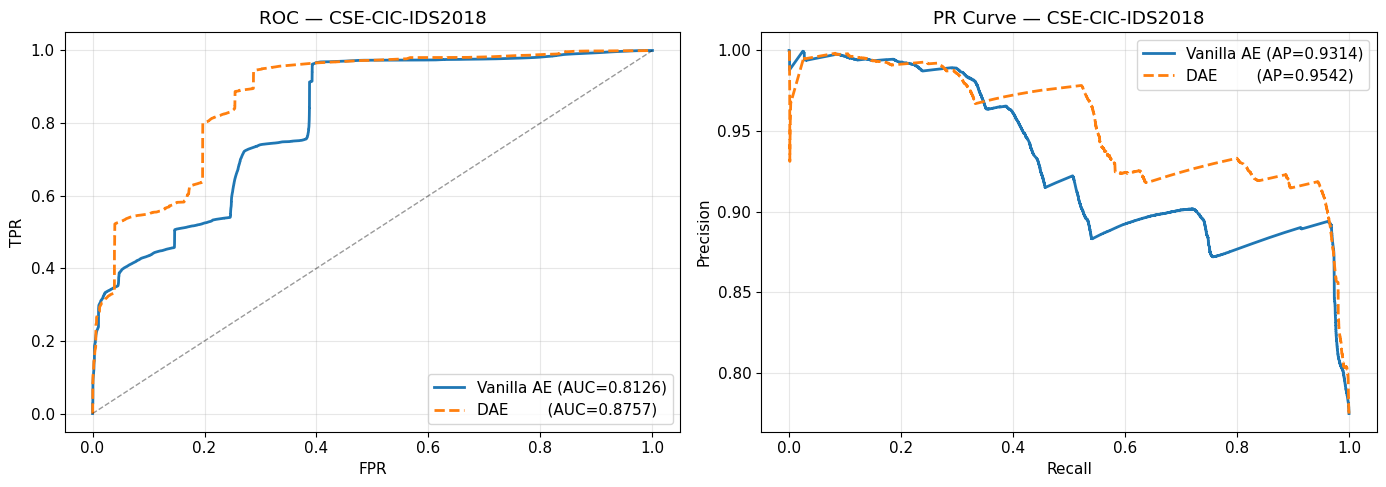

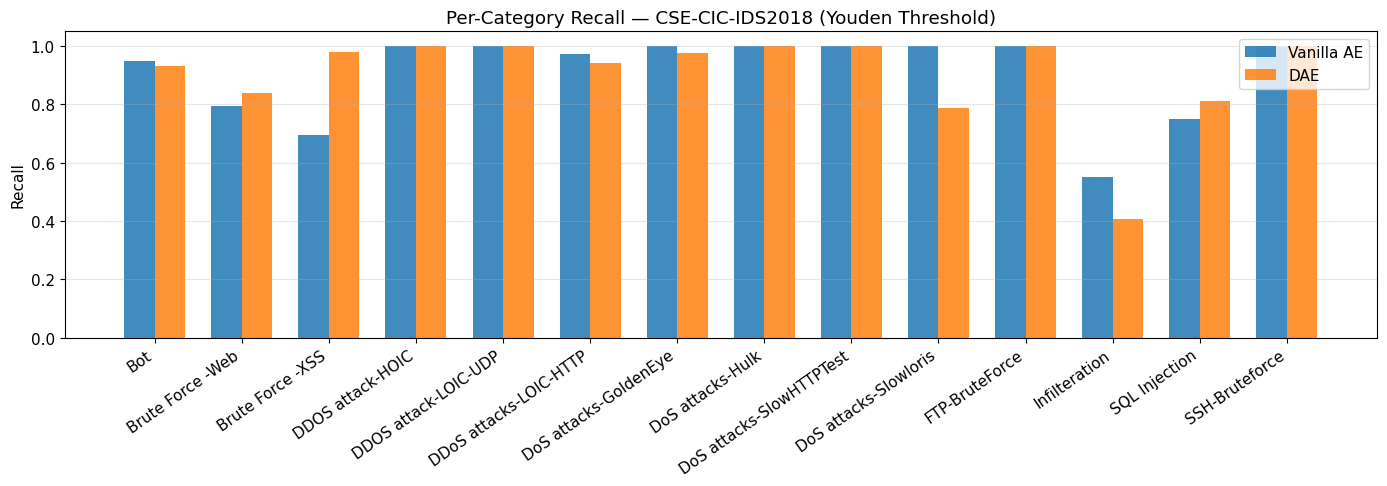

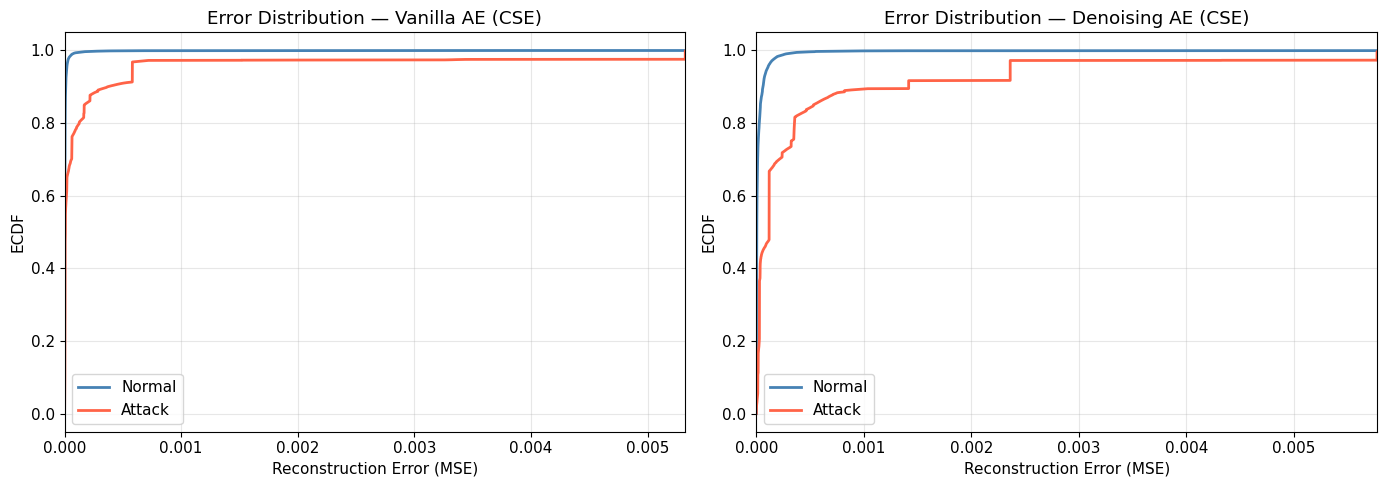

✅ Tüm CSE grafikleri kaydedildi


In [11]:
# ============================================================
# CSE CELL 11: ROC + PR + Per-Category Grafikleri
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({"font.size": 11})

# ROC + PR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(ae_fpr,  ae_tpr,  label=f"Vanilla AE (AUC={ae_roc:.4f})",  lw=2)
ax.plot(dae_fpr, dae_tpr, label=f"DAE        (AUC={dae_roc:.4f})", lw=2, ls="--")
ax.plot([0,1],[0,1],"k--",lw=1,alpha=0.4)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC — CSE-CIC-IDS2018"); ax.legend(); ax.grid(True, alpha=0.3)

prec_ae,  rec_ae,  _ = precision_recall_curve(y_test_np, ae_errors)
prec_dae, rec_dae, _ = precision_recall_curve(y_test_np, dae_errors)
ax2 = axes[1]
ax2.plot(rec_ae,  prec_ae,  label=f"Vanilla AE (AP={ae_pr:.4f})",  lw=2)
ax2.plot(rec_dae, prec_dae, label=f"DAE        (AP={dae_pr:.4f})", lw=2, ls="--")
ax2.set_xlabel("Recall"); ax2.set_ylabel("Precision")
ax2.set_title("PR Curve — CSE-CIC-IDS2018"); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_comparison_cse.png", dpi=150)
plt.show()

# Per-Category Bar Chart
df_cat = pd.DataFrame(cat_rows)
cats   = sorted(df_cat["category"].unique())
x      = np.arange(len(cats)); width = 0.35
fig, ax = plt.subplots(figsize=(14, 5))
ae_vals  = [df_cat[(df_cat.category==c)&(df_cat.model=="Vanilla AE")]["recall"].values[0] for c in cats]
dae_vals = [df_cat[(df_cat.category==c)&(df_cat.model=="DAE")]["recall"].values[0] for c in cats]
ax.bar(x - width/2, ae_vals,  width, label="Vanilla AE", alpha=0.85)
ax.bar(x + width/2, dae_vals, width, label="DAE",        alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=35, ha="right")
ax.set_ylabel("Recall"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Category Recall — CSE-CIC-IDS2018 (Youden Threshold)")
ax.legend(); ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "category_comparison_cse.png", dpi=150)
plt.show()

# ECDF
def ecdf(data): x=np.sort(data); return x, np.arange(1,len(x)+1)/len(x)
normal_mask = y_test_np == 0; attack_mask = y_test_np == 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, errors, title in zip(axes, [ae_errors, dae_errors], ["Vanilla AE", "Denoising AE"]):
    xn,yn = ecdf(errors[normal_mask]); xa,ya = ecdf(errors[attack_mask])
    ax.plot(xn,yn,label="Normal",color="steelblue",lw=2)
    ax.plot(xa,ya,label="Attack",color="tomato",lw=2)
    ax.set_xlim(0, np.percentile(errors, 99.5))
    ax.set_xlabel("Reconstruction Error (MSE)"); ax.set_ylabel("ECDF")
    ax.set_title(f"Error Distribution — {title} (CSE)")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "error_distribution_cse.png", dpi=150)
plt.show()
print("✅ Tüm CSE grafikleri kaydedildi")

In [12]:
# ============================================================
# FINAL CELL: Tüm Sonuçlar Özet Tablosu
# ============================================================
print("=" * 70)
print(f"{'Model':<22} {'Dataset':<16} {'ROC-AUC':>9} {'PR-AUC':>9}")
print("=" * 70)

rows = [
    ("Vanilla AE",       "UNSW-NB15 v2",    0.9874, 0.7490),
    ("DAE",              "UNSW-NB15 v2",    0.9714, 0.6155),
    ("Isolation Forest", "UNSW-NB15 v2",    0.8510, 0.1118),
    ("One-Class SVM",    "UNSW-NB15 v2",    0.7380, 0.2020),
    ("-"*20,             "-"*14,             0,      0     ),
    ("Vanilla AE",       "CSE-CIC-IDS2018", 0.8126, 0.9314),
    ("DAE",              "CSE-CIC-IDS2018", 0.8757, 0.9542),
]

for model, ds, roc, pr in rows:
    if model.startswith("-"):
        print("-" * 70)
    else:
        print(f"  {model:<20} {ds:<16} {roc:>9.4f} {pr:>9.4f}")
print("=" * 70)

# Üretilen tüm figürler
from pathlib import Path
print("\n📊 UNSW figürleri:")
for f in sorted(Path("/kaggle/working/unsw_v2").glob("*.png")):
    print(f"   {f.name}")
print("\n📊 CSE figürleri:")
for f in sorted(Path("/kaggle/working/cse_v1").glob("*.png")):
    print(f"   {f.name}")

Model                  Dataset            ROC-AUC    PR-AUC
  Vanilla AE           UNSW-NB15 v2        0.9874    0.7490
  DAE                  UNSW-NB15 v2        0.9714    0.6155
  Isolation Forest     UNSW-NB15 v2        0.8510    0.1118
  One-Class SVM        UNSW-NB15 v2        0.7380    0.2020
----------------------------------------------------------------------
  Vanilla AE           CSE-CIC-IDS2018     0.8126    0.9314
  DAE                  CSE-CIC-IDS2018     0.8757    0.9542

📊 UNSW figürleri:

📊 CSE figürleri:
   category_comparison_cse.png
   error_distribution_cse.png
   roc_comparison_cse.png
   training_curve_cse.png
